In [1]:
import pandas as pd
import time as t
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Weather- and Biddingzonedata Germany
de_bz_data = pd.read_csv("C:/Users/nicoh/Desktop/DSProject/BiddingZones/DE-LU_BZ.csv")
de_we_data = pd.read_csv("C:/Users/nicoh/Desktop/DSProject/Weatherdata/DE_Wetter.csv")
de_bz_data["country"] = "DE"
de_we_data["country"] = "DE"

# Weather- and Biddingzonedata Poland
pl_bz_data = pd.read_csv("C:/Users/nicoh/Desktop/DSProject/BiddingZones/PL_BZ.csv")
pl_we_data = pd.read_csv("C:/Users/nicoh/Desktop/DSProject/Weatherdata/PL_Wetter.csv")
pl_bz_data["country"] = "PL"
pl_we_data["country"] = "PL"

# Weather- and Biddingzonedata Finnland
fi_bz_data = pd.read_csv("C:/Users/nicoh/Desktop/DSProject/BiddingZones/FI_BZ.csv")
fi_we_data = pd.read_csv("C:/Users/nicoh/Desktop/DSProject/Weatherdata/FI_Wetter.csv")
fi_bz_data["country"] = "FI"
fi_we_data["country"] = "FI"

# Weather- and Biddingzonedata Czech Republic
cz_bz_data = pd.read_csv("C:/Users/nicoh/Desktop/DSProject/BiddingZones/CZ_BZ.csv")
cz_we_data = pd.read_csv("C:/Users/nicoh/Desktop/DSProject/Weatherdata/CZ_Wetter.csv")
cz_bz_data["country"] = "CZ"
cz_we_data["country"] = "CZ"

In [3]:
# Combination of weather data into two big dataframe
we_data = pd.concat([de_we_data, pl_we_data, fi_we_data, cz_we_data])
bz_data = pd.concat([de_bz_data, pl_bz_data, fi_bz_data, cz_bz_data])

In [4]:
# Cleanup of Time columns and introduction of pure date columns
bz_data["timestamp"] = pd.to_datetime(bz_data["timestamp"], utc=True)
we_data["time"] = pd.to_datetime(we_data["time"], utc=True)

bz_data["date"] = bz_data["timestamp"].dt.date
we_data["date"] = we_data["time"].dt.date

bz_data.columns = bz_data.columns.str.replace("values.", "", regex=False)

In [5]:
# Filter for common timewindows
bz_data = bz_data[(bz_data["timestamp"].dt.year >= 2019) & (bz_data["timestamp"].dt.year < 2025)]
we_data = we_data[(we_data["time"].dt.year >= 2019) & (we_data["time"].dt.year < 2025)]

In [6]:
# Weather- and Biddingzonedate aggregation for each country
we_agg = (
    we_data
    .groupby(["time","country"])
    .agg({
        "temperature_2m_max": "mean",
        "precipitation_sum": "mean",
        "shortwave_radiation_sum": "mean",
        "wind_speed_10m_mean": "mean",
        "soil_moisture_28_to_100cm_mean": "mean"
    })
    .reset_index()
)
we_agg["date"] = we_agg["time"].dt.date

bz_agg = (
    bz_data
    .groupby(["date","country"])["day_ahead_price"]
    .agg(
        price_mean="mean",
        price_std="std",
        price_min="min",
        price_max="max",
    )
    .reset_index()
)
bz_agg["price_range"] = bz_agg["price_max"] - bz_agg["price_min"] 

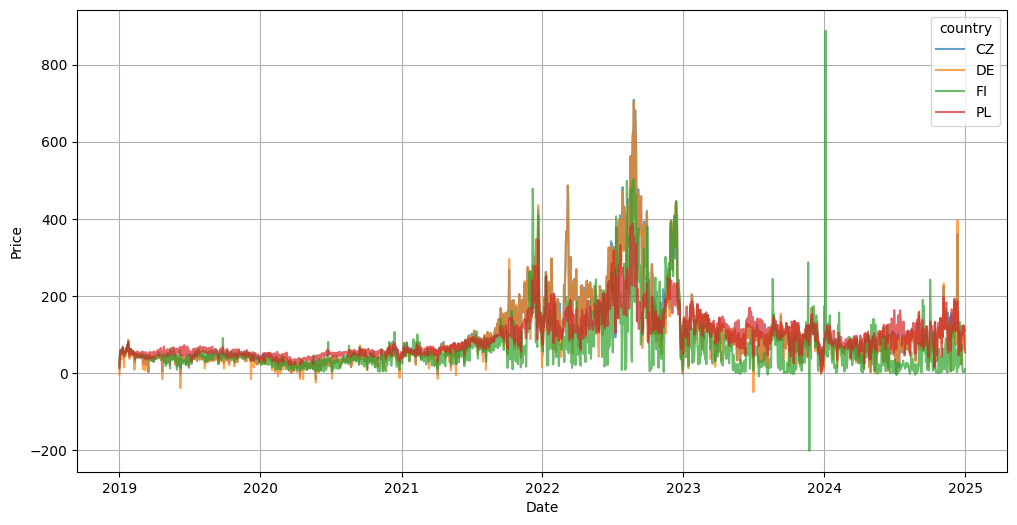

In [7]:
plot_data = bz_agg.pivot(
    index="date",
    columns="country",
    values="price_mean"
)

plot_data.plot(figsize=(12, 6),alpha=0.7)

plt.xlabel("Date")
plt.ylabel("Price")
plt.grid()
plt.show()

In [8]:
# Combination into large dataframe
daily = pd.merge(
    we_agg,
    bz_agg,
    on=["date", "country"],
    how="inner"
)
daily["date"] = pd.to_datetime(daily["date"])
daily["month"] = daily["date"].dt.month
daily["year"] = daily["date"].dt.year

In [ ]:
# Calculating thresholds for "extreme weather" (tho its probably more "unusual weather")
c_list = []
for c in ["DE", "FI", "PL", "CZ"]:

    temp = daily[daily["country"] == c]

    for i in range(1,13):

        m = temp[daily["month"] == i]
        val = [c, i, float(m["temperature_2m_max"].quantile(0.90)), float(m["wind_speed_10m_mean"].quantile(0.10)), float(m["shortwave_radiation_sum"].quantile(0.10)), float(m["soil_moisture_28_to_100cm_mean"].quantile(0.10))]
        c_list.append(val)

df_threshold = pd.DataFrame(c_list, columns=["country", "month", "temp_90", "wind_10", "solar_10", "soil_10"])

In [10]:
# Combination into large dataframe
daily_enriched = pd.merge(
    daily,
    df_threshold,
    on=["month", "country"],
    how="inner"
)

In [11]:
# Finding out of the ordinary candidates
daily_enriched["high_heat_candidate"] = (daily_enriched["temperature_2m_max"]             >= daily_enriched["temp_90"])
daily_enriched["low_wind_candidate"]  = (daily_enriched["wind_speed_10m_mean"]            <= daily_enriched["wind_10"])
daily_enriched["low_solar_candidate"] = (daily_enriched["shortwave_radiation_sum"]        <= daily_enriched["solar_10"])
daily_enriched["low_soil_candidate"]  = (daily_enriched["soil_moisture_28_to_100cm_mean"] <= daily_enriched["soil_10"])

In [12]:
# Find unusual weather periods
daily_enriched = daily_enriched.sort_values(["country","date"])

# High heat (3 days)
daily_enriched["high_heat"] = (
    daily_enriched["high_heat_candidate"]
    &   (
        (daily_enriched["high_heat_candidate"].shift(1, fill_value=False) & daily_enriched["high_heat_candidate"].shift(-1, fill_value=False))
        | (daily_enriched["high_heat_candidate"].shift(1, fill_value=False) & daily_enriched["high_heat_candidate"].shift(2, fill_value=False))
        | (daily_enriched["high_heat_candidate"].shift(-1, fill_value=False) & daily_enriched["high_heat_candidate"].shift(-2, fill_value=False))
        )
    )

# Low heat (3 days)
daily_enriched["low_wind"] = (
    daily_enriched["low_wind_candidate"]
    &   (
        (daily_enriched["low_wind_candidate"].shift(1, fill_value=False) & daily_enriched["low_wind_candidate"].shift(-1, fill_value=False))
        | (daily_enriched["low_wind_candidate"].shift(1, fill_value=False) & daily_enriched["low_wind_candidate"].shift(2, fill_value=False))
        | (daily_enriched["low_wind_candidate"].shift(-1, fill_value=False) & daily_enriched["low_wind_candidate"].shift(-2, fill_value=False))
        )
    )

# Low solar (3 days)
daily_enriched["low_solar"] = (
    daily_enriched["low_solar_candidate"]
    &   (
        (daily_enriched["low_solar_candidate"].shift(1, fill_value=False) & daily_enriched["low_solar_candidate"].shift(-1, fill_value=False))
        | (daily_enriched["low_solar_candidate"].shift(1, fill_value=False) & daily_enriched["low_solar_candidate"].shift(2, fill_value=False))
        | (daily_enriched["low_solar_candidate"].shift(-1, fill_value=False) & daily_enriched["low_solar_candidate"].shift(-2, fill_value=False))
        )
    )

# Low soil (3 days)
daily_enriched["low_soil"] = (
    daily_enriched["low_soil_candidate"]
    &   (
        (daily_enriched["low_soil_candidate"].shift(1, fill_value=False) & daily_enriched["low_soil_candidate"].shift(-1, fill_value=False))
        | (daily_enriched["low_soil_candidate"].shift(1, fill_value=False) & daily_enriched["low_soil_candidate"].shift(2, fill_value=False))
        | (daily_enriched["low_soil_candidate"].shift(-1, fill_value=False) & daily_enriched["low_soil_candidate"].shift(-2, fill_value=False))
        )
    )

# If there was a Weather event of any kind on a given day
daily_enriched["weather_event"] = (daily_enriched["high_heat"] | daily_enriched["low_wind"] | daily_enriched["low_solar"] | daily_enriched["low_soil"])

In [20]:
daily_enriched_agg_wind = daily_enriched.groupby(["country", "year", "month", "low_wind"])["price_std"].agg(["mean","count"]).reset_index()
daily_enriched_agg_heat = daily_enriched.groupby(["country", "year", "month", "high_heat"])["price_std"].agg(["mean","count"]).reset_index()
daily_enriched_agg_solar = daily_enriched.groupby(["country", "year", "month", "low_solar"])["price_std"].agg(["mean","count"]).reset_index()
daily_enriched_agg_soil = daily_enriched.groupby(["country", "year", "month", "low_soil"])["price_std"].agg(["mean","count"]).reset_index()
daily_enriched_agg = daily_enriched.groupby(["country", "year", "month", "weather_event"])["price_std"].agg(["mean","count"]).reset_index()

In [342]:
display(daily_enriched_agg[(daily_enriched_agg["country"] == "DE")])

,country,year,month,low_wind,mean,count
86,DE,2019,1,False,48.306324,28
87,DE,2019,1,True,59.750694,3
88,DE,2019,2,False,42.746910,24
89,DE,2019,2,True,43.220833,4
90,DE,2019,3,False,30.614852,31
...,...,...,...,...,...,...
164,DE,2024,9,False,78.064889,30
165,DE,2024,10,False,86.292997,31
166,DE,2024,11,False,113.956889,30
167,DE,2024,12,False,107.272531,27


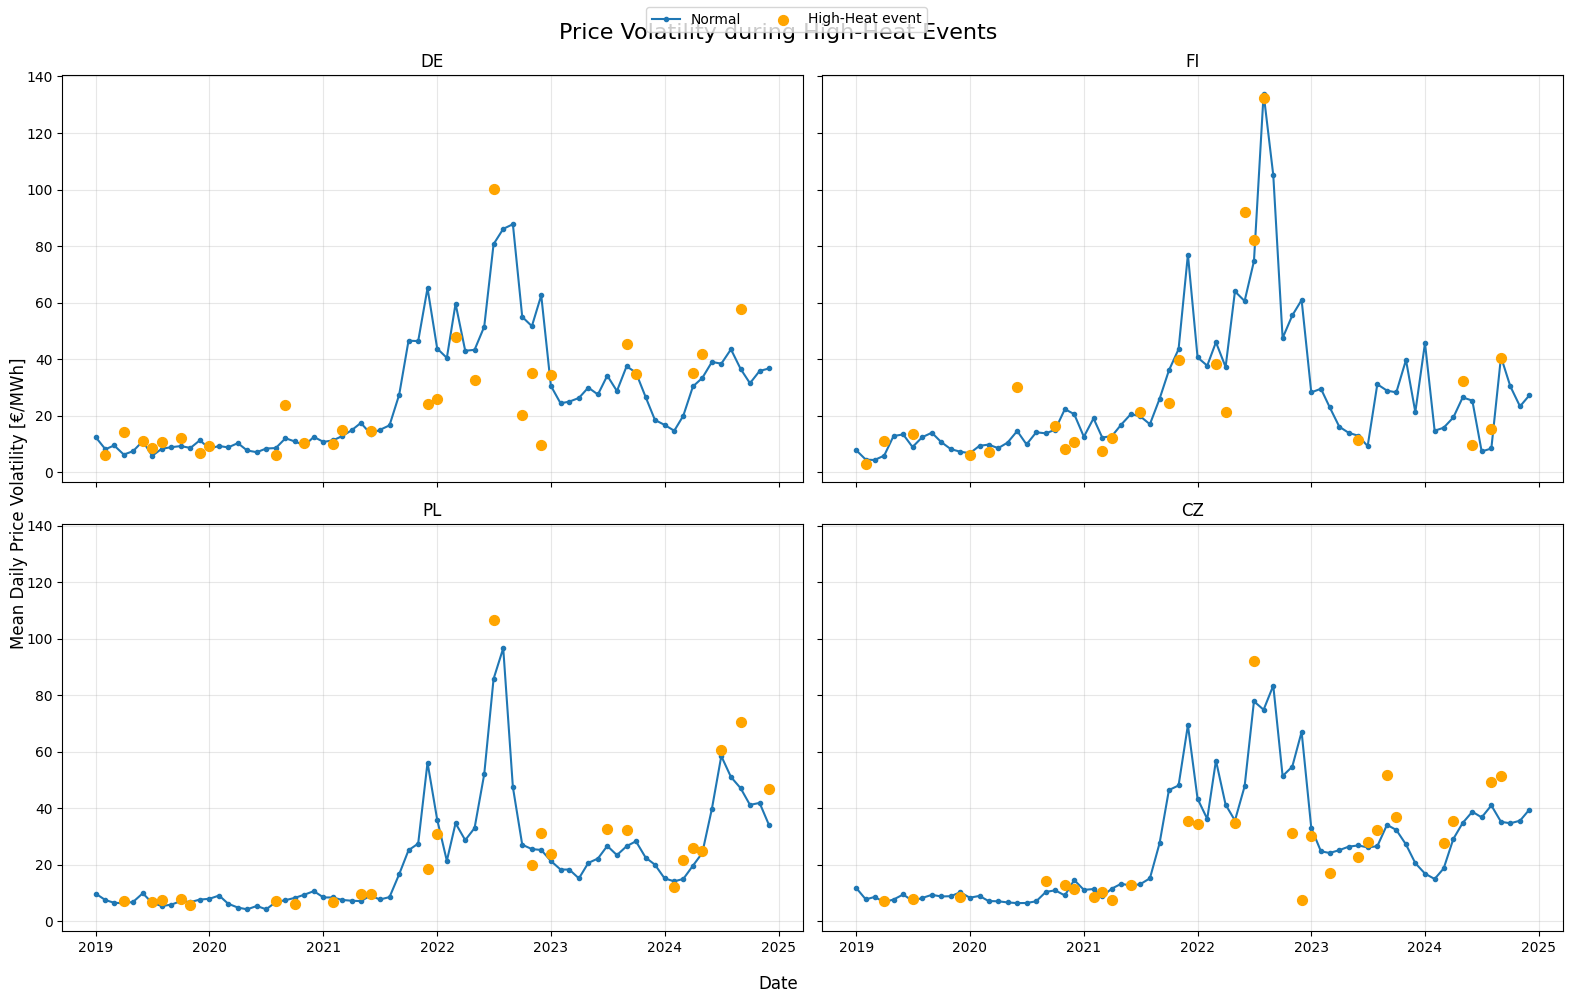

In [27]:
countries = ["DE", "FI", "PL", "CZ"]
event = "high_heat"

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, country in zip(axes, countries):

    data = daily_enriched_agg_heat[
        daily_enriched_agg_heat["country"] == country
    ].copy()

    data["date"] = pd.to_datetime(
        dict(
            year=data["year"],
            month=data["month"],
            day=1
        )
    )

    normal = data[data[event] == False]
    extreme = data[data[event] == True]

    # normale Tage
    ax.plot(
        normal["date"],
        normal["mean"],
        marker="o",
        markersize=3,
        label="Normal"
    )

    # Event-Tage
    ax.scatter(
        extreme["date"],
        extreme["mean"],
        s=50,
        label="High-Heat event",
        c="orange",
        zorder=3
    )

    ax.set_title(country)
    ax.grid(alpha=0.3)

fig.suptitle(
    "Price Volatility during High-Heat Events",
    fontsize=16
)

fig.supxlabel("Date")
fig.supylabel("Mean Daily Price Volatility [€/MWh]")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2
)

plt.tight_layout()
plt.show()

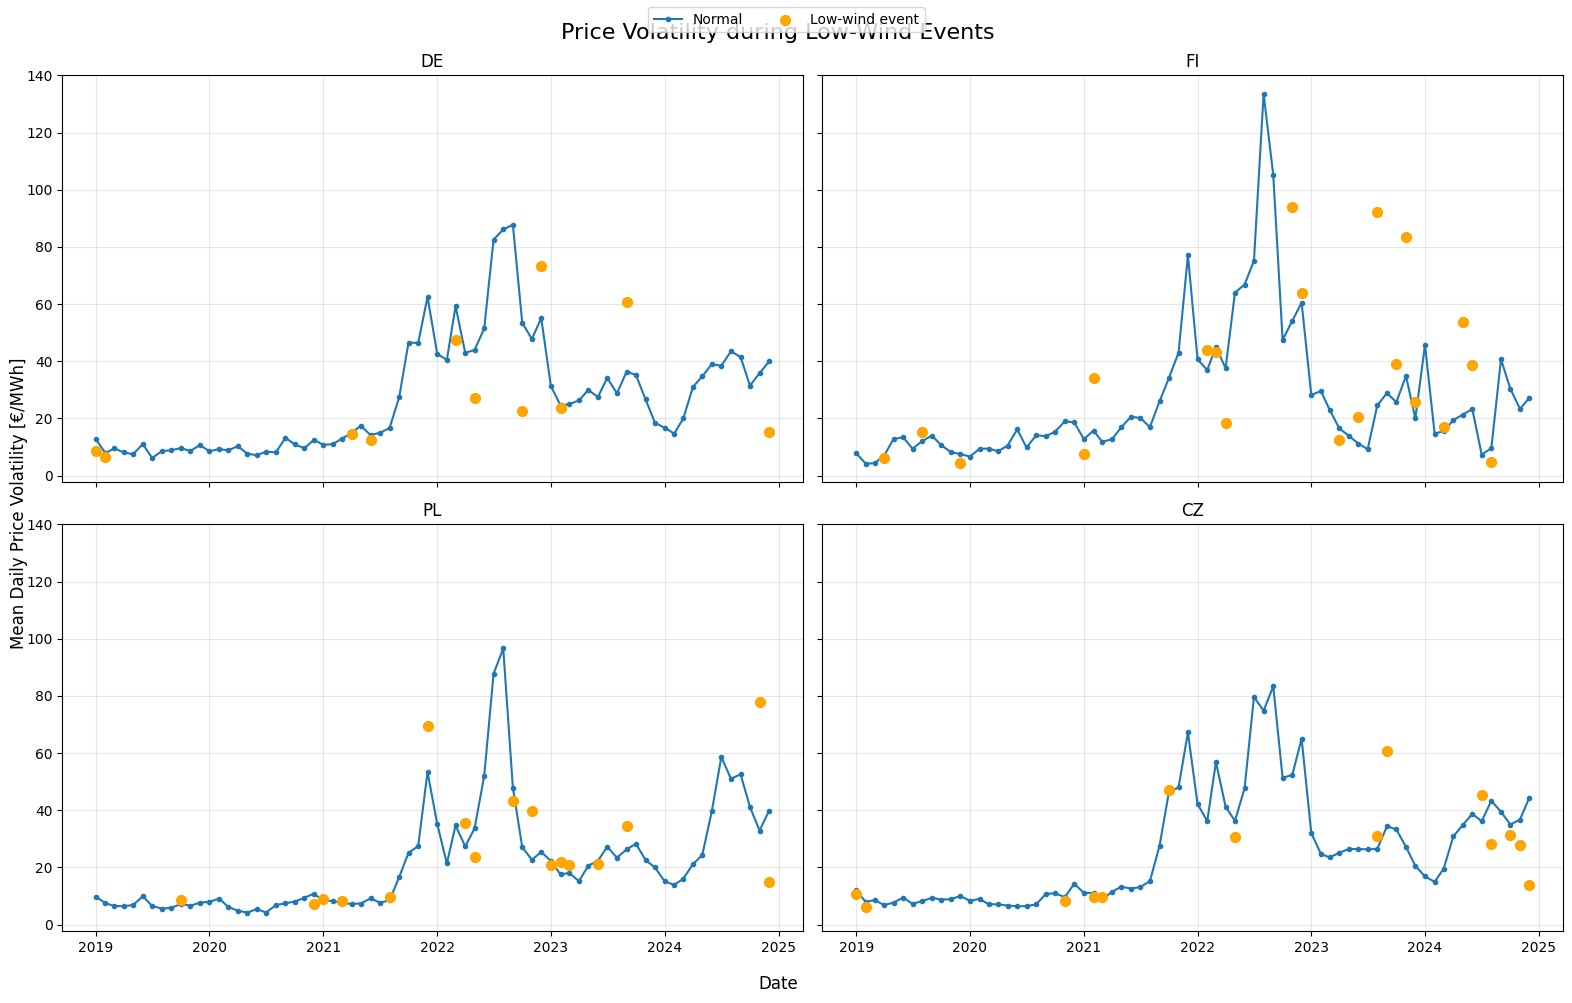

In [26]:
countries = ["DE", "FI", "PL", "CZ"]
event = "low_wind"

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, country in zip(axes, countries):

    data = daily_enriched_agg_wind[
        daily_enriched_agg_wind["country"] == country
    ].copy()

    data["date"] = pd.to_datetime(
        dict(
            year=data["year"],
            month=data["month"],
            day=1
        )
    )

    normal = data[data[event] == False]
    extreme = data[data[event] == True]

    # normale Tage
    ax.plot(
        normal["date"],
        normal["mean"],
        marker="o",
        markersize=3,
        label="Normal"
    )

    # Event-Tage
    ax.scatter(
        extreme["date"],
        extreme["mean"],
        s=50,
        label="Low-wind event",
        c="orange",
        zorder=3
    )

    ax.set_title(country)
    ax.grid(alpha=0.3)

fig.suptitle(
    "Price Volatility during Low-Wind Events",
    fontsize=16
)

fig.supxlabel("Date")
fig.supylabel("Mean Daily Price Volatility [€/MWh]")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2
)

plt.tight_layout()
plt.show()

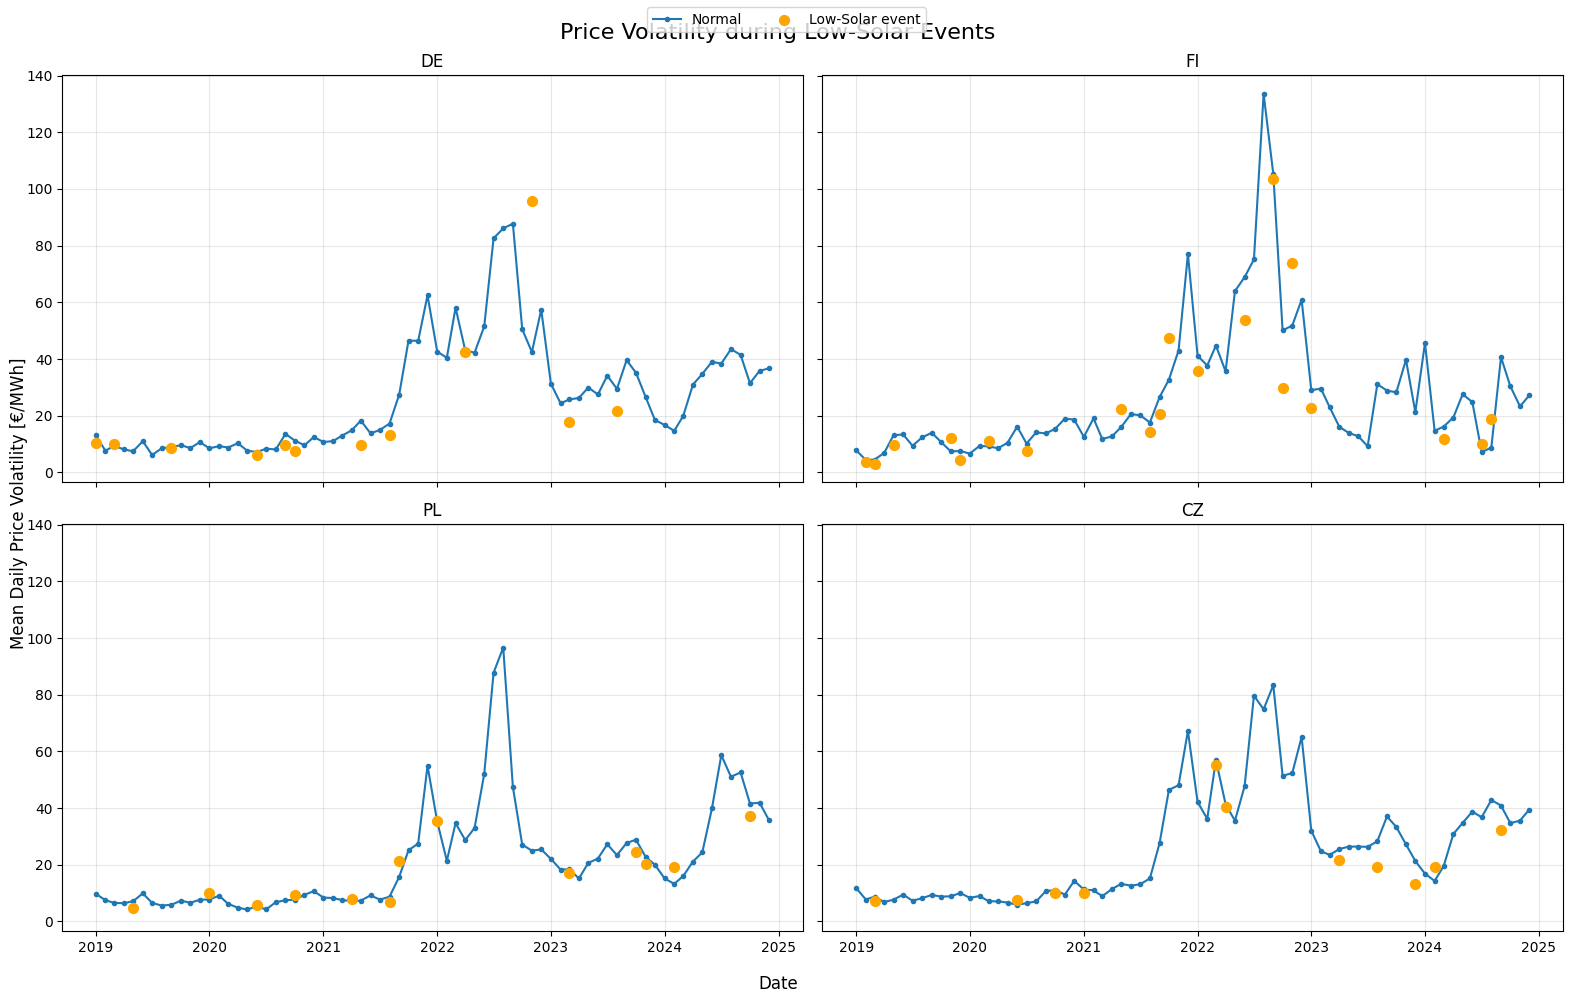

In [25]:
countries = ["DE", "FI", "PL", "CZ"]
event = "low_solar"

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, country in zip(axes, countries):

    data = daily_enriched_agg_solar[
        daily_enriched_agg_solar["country"] == country
    ].copy()

    data["date"] = pd.to_datetime(
        dict(
            year=data["year"],
            month=data["month"],
            day=1
        )
    )

    normal = data[data[event] == False]
    extreme = data[data[event] == True]

    # normale Tage
    ax.plot(
        normal["date"],
        normal["mean"],
        marker="o",
        markersize=3,
        label="Normal"
    )

    # Event-Tage
    ax.scatter(
        extreme["date"],
        extreme["mean"],
        s=50,
        label="Low-Solar event",
        c="orange",
        zorder=3
    )

    ax.set_title(country)
    ax.grid(alpha=0.3)

fig.suptitle(
    "Price Volatility during Low-Solar Events",
    fontsize=16
)

fig.supxlabel("Date")
fig.supylabel("Mean Daily Price Volatility [€/MWh]")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2
)

plt.tight_layout()
plt.show()

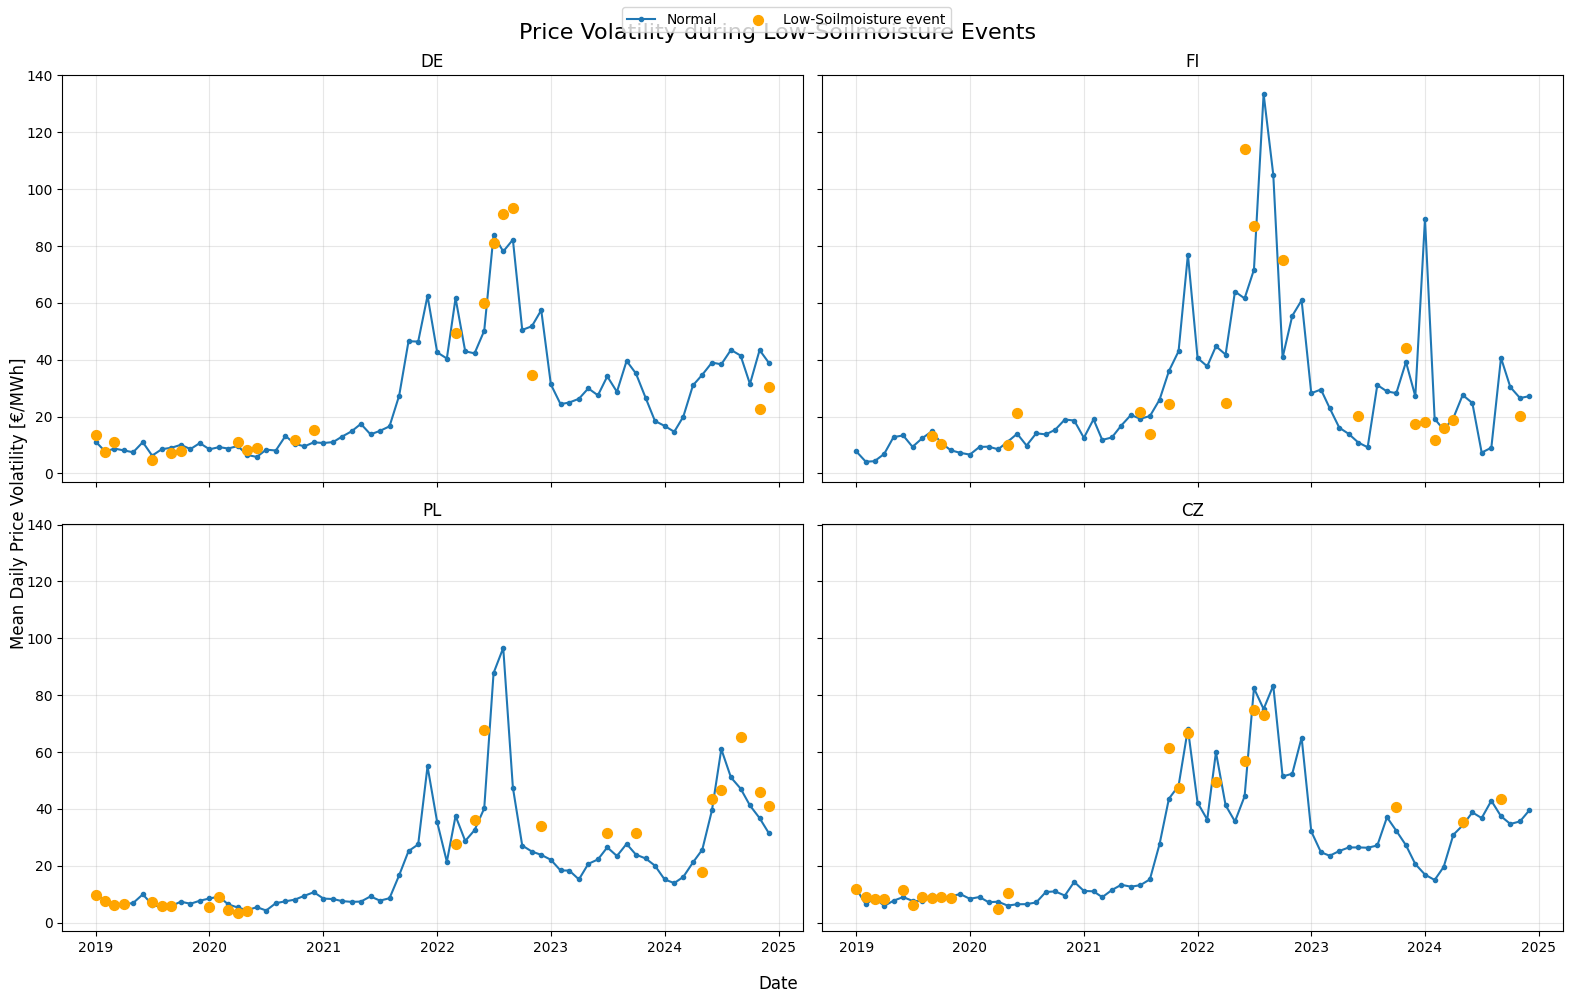

In [24]:
countries = ["DE", "FI", "PL", "CZ"]
event = "low_soil"

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, country in zip(axes, countries):

    data = daily_enriched_agg_soil[
        daily_enriched_agg_soil["country"] == country
    ].copy()

    data["date"] = pd.to_datetime(
        dict(
            year=data["year"],
            month=data["month"],
            day=1
        )
    )

    normal = data[data[event] == False]
    extreme = data[data[event] == True]

    # normale Tage
    ax.plot(
        normal["date"],
        normal["mean"],
        marker="o",
        markersize=3,
        label="Normal"
    )

    # Event-Tage
    ax.scatter(
        extreme["date"],
        extreme["mean"],
        s=50,
        label="Low-Soilmoisture event",
        c="orange",
        zorder=3
    )

    ax.set_title(country)
    ax.grid(alpha=0.3)

fig.suptitle(
    "Price Volatility during Low-Soilmoisture Events",
    fontsize=16
)

fig.supxlabel("Date")
fig.supylabel("Mean Daily Price Volatility [€/MWh]")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2
)

plt.tight_layout()
plt.show()

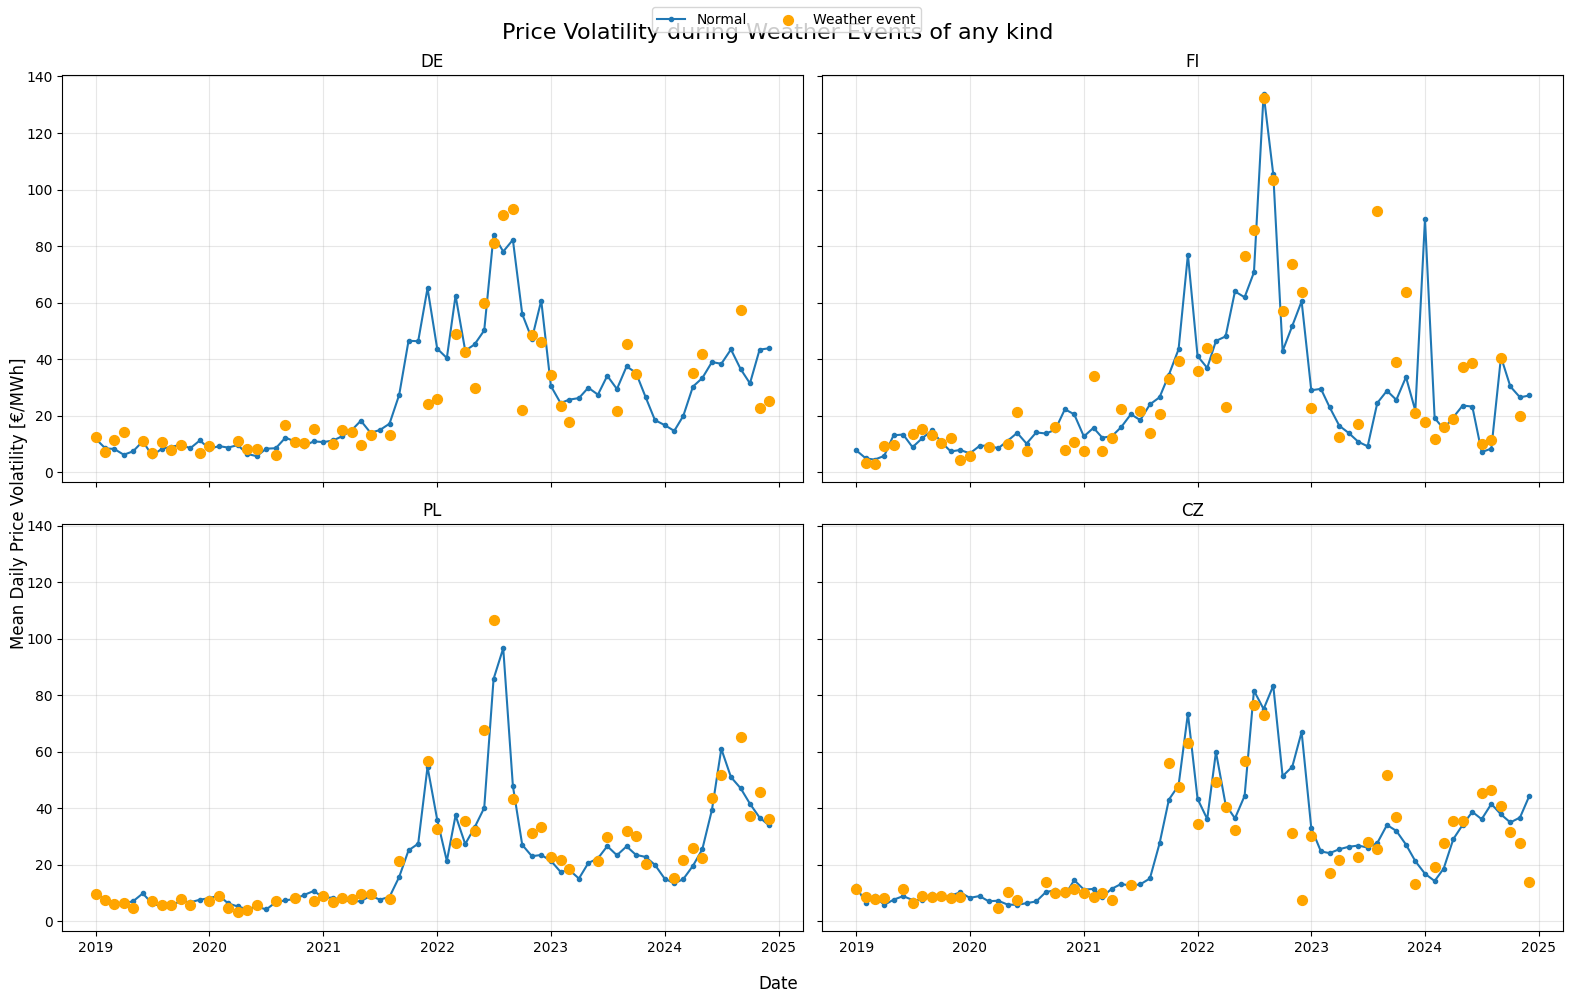

In [23]:
countries = ["DE", "FI", "PL", "CZ"]
event = "weather_event"

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, country in zip(axes, countries):

    data = daily_enriched_agg[
        daily_enriched_agg["country"] == country
    ].copy()

    data["date"] = pd.to_datetime(
        dict(
            year=data["year"],
            month=data["month"],
            day=1
        )
    )

    normal = data[data[event] == False]
    extreme = data[data[event] == True]

    # normale Tage
    ax.plot(
        normal["date"],
        normal["mean"],
        marker="o",
        markersize=3,
        label="Normal"
    )

    # Event-Tage
    ax.scatter(
        extreme["date"],
        extreme["mean"],
        s=50,
        label="Weather event",
        c="orange",
        zorder=3
    )

    ax.set_title(country)
    ax.grid(alpha=0.3)

fig.suptitle(
    "Price Volatility during Weather Events of any kind",
    fontsize=16
)

fig.supxlabel("Date")
fig.supylabel("Mean Daily Price Volatility [€/MWh]")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2
)

plt.tight_layout()
plt.show()

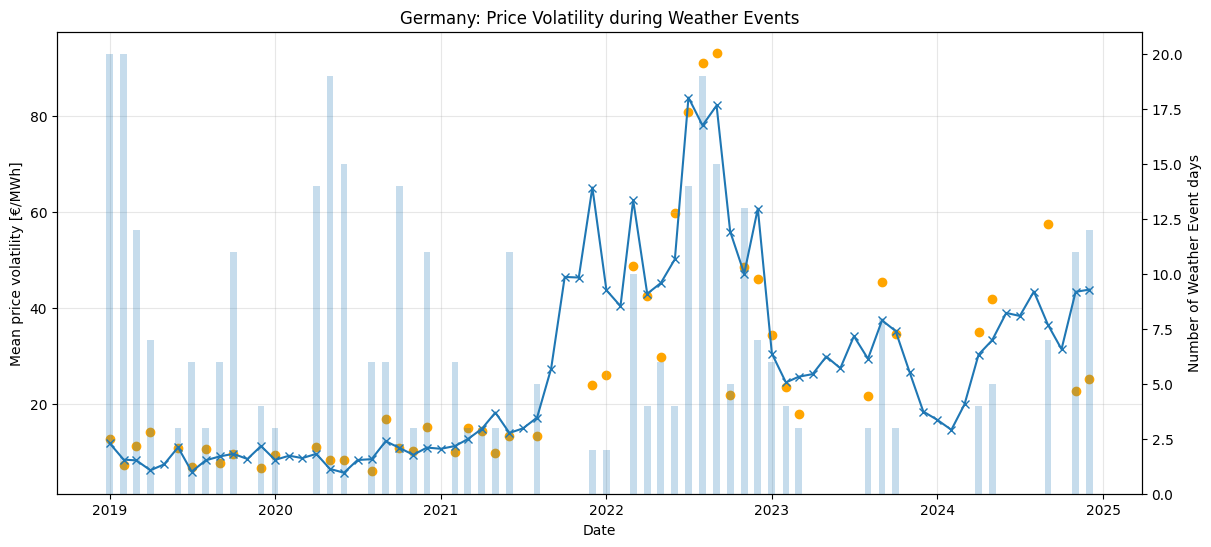

In [359]:
de = daily_enriched_agg[
    daily_enriched_agg["country"] == "DE"
].copy()

de["date"] = pd.to_datetime(
    dict(year=de["year"], month=de["month"], day=1)
)

normal = de[de["weather_event"] == False]
weather_event = de[de["weather_event"] == True]

fig, ax1 = plt.subplots(figsize=(14, 6))


# Preisvolatilität
ax1.plot(
    normal["date"],
    normal["mean"],
    label="Mean price volatility",
    marker="x"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Mean price volatility [€/MWh]")
ax1.grid(alpha=0.3)

ax1.scatter(
    weather_event["date"],
    weather_event["mean"],
    label="Mean price volatility",
    c="orange"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Mean price volatility [€/MWh]")
ax1.grid(alpha=0.3)

# zweite Y-Achse
ax2 = ax1.twinx()

ax2.bar(
    weather_event["date"],
    weather_event["count"],
    width=15,
    alpha=0.25,
    label="Low-wind days"
)

ax2.set_ylabel("Number of Weather Event days")

plt.title("Germany: Price Volatility during Weather Events")
plt.show()

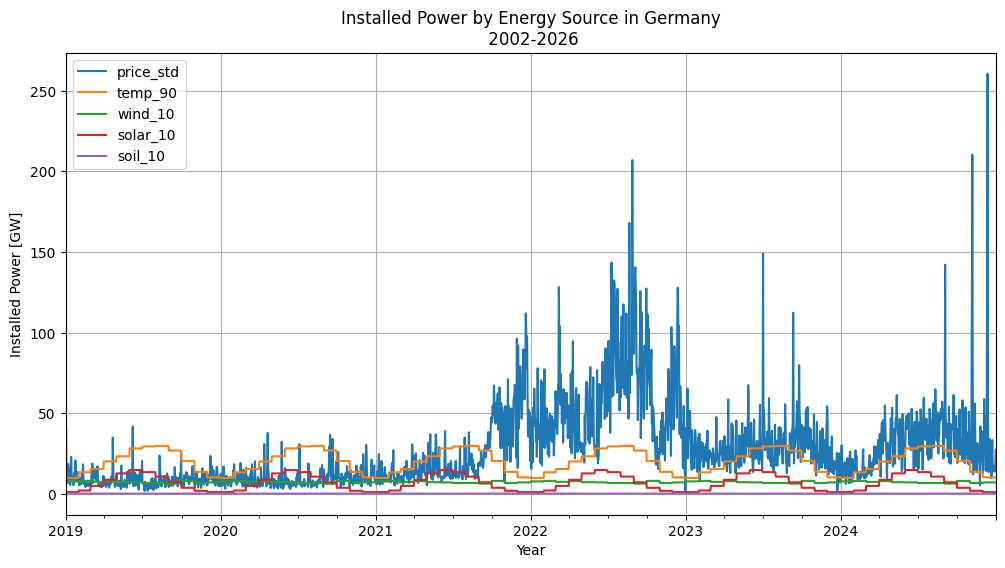

In [ ]:
daily_enriched_de = daily_enriched[daily_enriched["country"] == "DE"]
daily_enriched_de.plot(
    x="date",
    y=[
        "price_std"
        ,"temp_90"
        ,"wind_10"
        ,"solar_10"
        ,"soil_10"
    ],
    figsize=(12, 6)
)

plt.xlabel("Year")
plt.ylabel("Installed Power [GW]")
plt.title("Installed Power by Energy Source in Germany\n 2002-2026")
plt.grid()
plt.show()

In [ ]:
x = de_daily["precipitation_sum"]
y = de_daily["price_mean"]

plt.figure(figsize=(8, 6))

plt.scatter(
    x,
    y,
    alpha=0.3
)

# Linearen Trend fitten
m, b = np.polyfit(x, y, 1)

# Trendlinie
plt.plot(
    x,
    m * x + b,
    color="red",
    linewidth=2
)
plt.xlabel("Daily max precipitation")
plt.ylabel("Daily mean electricity price")
plt.title("Precipitation vs. Electricity Price - Germany")

plt.show()

NameError: name 'de_daily' is not defined

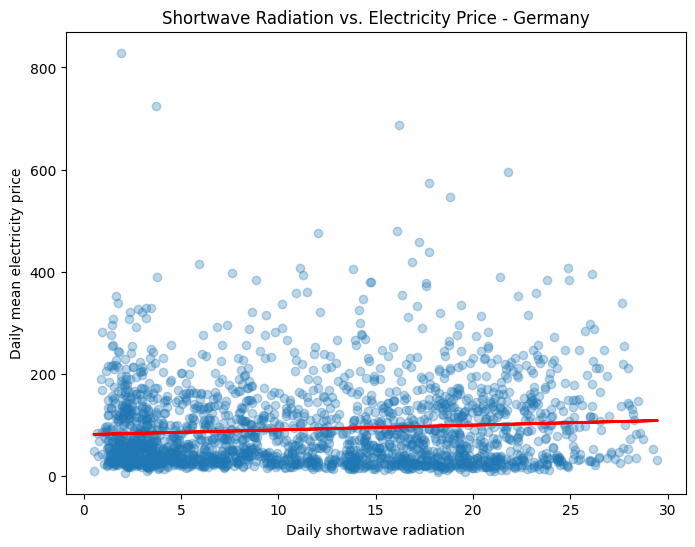

In [ ]:
x = de_daily["shortwave_radiation_sum"]
y = de_daily["price_min_max_diff"]

plt.figure(figsize=(8, 6))

plt.scatter(
    x,
    y,
    alpha=0.3
)

# Linearen Trend fitten
m, b = np.polyfit(x, y, 1)

# Trendlinie
plt.plot(
    x,
    m * x + b,
    color="red",
    linewidth=2
)
plt.xlabel("Daily shortwave radiation")
plt.ylabel("Daily mean electricity price")
plt.title("Shortwave Radiation vs. Electricity Price - Germany")

plt.show()

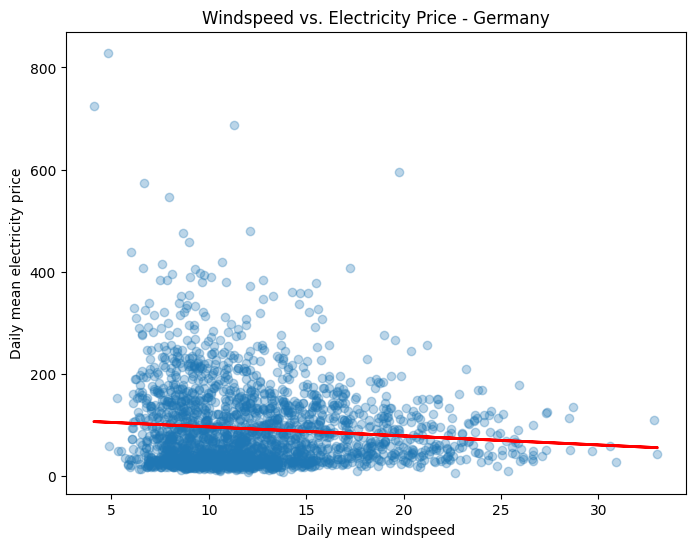

In [ ]:
x = de_daily["wind_speed_10m_mean"]
y = de_daily["price_min_max_diff"]

plt.figure(figsize=(8, 6))

plt.scatter(
    x,
    y,
    alpha=0.3
)

# Linearen Trend fitten
m, b = np.polyfit(x, y, 1)

# Trendlinie
plt.plot(
    x,
    m * x + b,
    color="red",
    linewidth=2
)

plt.xlabel("Daily mean windspeed")
plt.ylabel("Daily mean electricity price")
plt.title("Windspeed vs. Electricity Price - Germany")

plt.show()